#### Dataset
- Name: Titanic Dataset
- Task: Binary Classification
- Source: Kaggle
- Reference: Link: https://www.kaggle.com/c/titanic


<h1> Bayesian Networks

Here, we delve into one of the most important concepts of probabilistic reasoning in AI.

So far, we have covered:

Single Probability
↓
Conditional Probability
↓
Bayes' Theorem

Now, we aim to model multiple random variables and the relationships between them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

from src.bayes import (
    Node,
    joint_probability,
    BayesianNetwork
)

c:\Users\niush\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


<h3> Step 1: Simple Graph Structure

In [2]:
cloudy = Node(
    "Cloudy"
)

rain = Node(
    "Rain"
)

wet_grass = Node(
    "Wet Grass"
)

rain.add_parent(
    cloudy
)

wet_grass.add_parent(
    rain
)

In [3]:
print(
    rain.parents[0].name
)

Cloudy


A Bayesian network allows us to decompose the joint probability.

In other words:</br>
Instead of storing a very large table, we divide it into smaller sections.

In [4]:
cloudy.cpt = {
    True: 0.5,
    False: 0.5
}

rain.cpt = {
    (True,): 0.8,
    (False,): 0.2
}

wet_grass.cpt = {
    (True,): 0.9,
    (False,): 0.1
}

Visualization

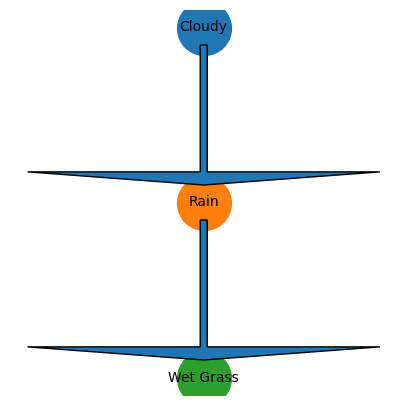

In [5]:
positions = {
    "Cloudy":(0,2),
    "Rain":(0,1),
    "Wet Grass":(0,0)
}

edges = [
    ("Cloudy","Rain"),
    ("Rain","Wet Grass")
]

plt.figure(
    figsize=(5,5)
)

for node,pos in positions.items():
    plt.scatter(
        pos[0],
        pos[1],
        s=1500
    )
    plt.text(
        pos[0],
        pos[1],
        node,
        ha="center",
        va="center"
    )

for start,end in edges:
    x1,y1 = positions[start]
    x2,y2 = positions[end]

    plt.arrow(
        x1,
        y1-0.1,
        x2-x1,
        y2-y1+0.2,
        head_width=0.05,
        length_includes_head=True
    )

plt.axis("off")
plt.show()

<h3> Step 2: Inference in Bayesian Networks

So far, we have only constructed the network; however, the primary purpose of a Bayesian Network is not merely to store relationships. The goal is to be able to ask probabilistic questions.</br>
For example:</br> If we know the grass is wet, what is the probability of rain?

That is:

$P(Rain | WetGrass)$

The concept of inference: calculating the probability of a variable given new information.

P(Cloudy=True)=0.5

P(Rain=True|Cloudy=True)=0.8

P(Wet=True|Rain=True)=0.9

In [6]:
joint_probability(
    True,
    True,
    True
)

0.36000000000000004

$P(Rain=True | Wet=True)$

In [7]:
numerator = (
    joint_probability(
        True,
        True,
        True
    )
    +
    joint_probability(
        False,
        True,
        True
    )
)

numerator

0.45000000000000007

In [8]:
denominator = 0

for cloudy in [True,False]:
    for rain in [True,False]:
        denominator += joint_probability(
            cloudy,
            rain,
            True
        )

denominator

0.5000000000000001

In [9]:
posterior = (
    numerator /
    denominator
)

posterior

0.8999999999999999

<h3> Step 3: Real-world Example — Titanic Bayesian Network

Objective of this section:

To build a simple Bayesian Network from real data and perform inference.

Instead of classical prediction, we aim to answer probabilistic questions:

For example:</br>
If we know the passenger was female, what is the probability of survival?

Or:</br>
If the passenger was female and in first class, what is the probability of survival?

In [10]:
df = pd.read_csv(
    "../datasets/Titanic-Dataset/raw/Titanic-Dataset.csv"
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


For a small Bayesian Network, we limit the number of variables.
Selection:
- Sex
- Pclass
- Survived

Reason:
These three features have a clear probabilistic relationship.

In [11]:
titanic_bn = df[
    [
        "Sex",
        "Pclass",
        "Survived"
    ]
].copy()

titanic_bn["Sex"] = (
    titanic_bn["Sex"]
    .map(
        {
            "female":1,
            "male":0
        }
    )
)

titanic_bn.head()

,Sex,Pclass,Survived
0,0,3,0
1,1,1,1
2,1,3,1
3,1,1,1
4,0,3,0


$P(Survived)$

In [12]:
prior_survival = (
    titanic_bn["Survived"]
    .mean()
)

prior_survival

0.3838383838383838

$P(Survival|Sex)$

In [13]:
sex_survival = (
    titanic_bn
    .groupby("Sex")["Survived"]
    .mean()
)

sex_survival

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

Male survival ≈ 19%

Female survival ≈ 74%

$P(Survival|Pclass)$

In [14]:
class_survival = (
    titanic_bn
    .groupby("Pclass")["Survived"]
    .mean()
)

class_survival

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

<h3> Step 3: Inference Function

In [15]:
def query_survival(
    sex=None,
    pclass=None
):
    data = titanic_bn
    if sex is not None:
        data = data[
            data["Sex"] == sex
        ]
    if pclass is not None:
        data = data[
            data["Pclass"] == pclass
        ]
    return data["Survived"].mean()

In [16]:
query_survival()

0.3838383838383838

In [17]:
query_survival(
    sex=1
)

0.7420382165605095

$Female + First Class$

In [18]:
query_survival(
    sex=1,
    pclass=1
)

0.9680851063829787

<h3> Visualization

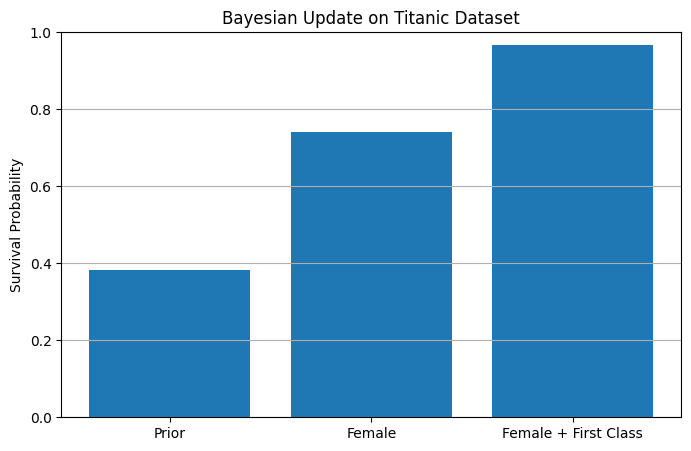

In [19]:
cases = [
    "Prior",
    "Female",
    "Female + First Class"
]

probabilities = [
    query_survival(),
    query_survival(
        sex=1
    ),
    query_survival(
        sex=1,
        pclass=1
    )
]

plt.figure(
    figsize=(8,5)
)

plt.bar(
    cases,
    probabilities
)

plt.ylim(
    0,
    1
)

plt.ylabel(
    "Survival Probability"
)

plt.title(
    "Bayesian Update on Titanic Dataset"
)

plt.grid(
    axis="y"
)

plt.show()

<h3> Step 4: Building a Network Engine for Titanic

In [20]:
titanic_data = df[
    [
        "Sex",
        "Pclass",
        "Survived"
    ]
].copy()

In [21]:
titanic_data["Sex"] = (
    titanic_data["Sex"]
    .map(
        {
            "female": 1,
            "male": 0
        }
    )
)

titanic_network = BayesianNetwork()

titanic_network.fit(
    titanic_data
)


titanic_network.query(
    "Survived",
    {
        "Sex":1,
        "Pclass":1
    }
)

     Sex  Pclass  Survived
1      1       1         1
3      1       1         1
11     1       1         1
31     1       1         1
52     1       1         1
..   ...     ...       ...
856    1       1         1
862    1       1         1
871    1       1         1
879    1       1         1
887    1       1         1

[94 rows x 3 columns]


0.9680851063829787

<h3> Step 5: Learning CPTs from data (learn_cpt)

In [22]:
titanic_network = BayesianNetwork()

titanic_network.add_node(
    Node("Sex")
)

titanic_network.add_node(
    Node("Pclass")
)

titanic_network.add_node(
    Node("Survived")
)

titanic_network.add_edge(
    "Sex",
    "Survived"
)

titanic_network.add_edge(
    "Pclass",
    "Survived"
)

In [23]:
titanic_network.fit(
    titanic_data
)

titanic_network.learn_cpt()

titanic_network.nodes["Survived"].cpt

Sex  Pclass  Sex  Pclass  Survived
0    1       0    1       0           0.631148
                          1           0.368852
     2       0    2       0           0.842593
                          1           0.157407
     3       0    3       0           0.864553
                          1           0.135447
1    1       1    1       0           0.031915
                          1           0.968085
     2       1    2       0           0.078947
                          1           0.921053
     3       1    3       0           0.500000
                          1           0.500000
dtype: float64